# Proyecto de Business Intelligence — COVID-19 Global Dataset
## Fase 1: Comprensión del Problema

**Dataset fuente:** [Corona Virus Report — Kaggle (imdevskp)](https://www.kaggle.com/datasets/imdevskp/corona-virus-report)  
**Archivo utilizado:** `covid_19_clean_complete.csv`  

## 1. Importación de librerías y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

NUM_COLS = ['Confirmed', 'Deaths', 'Recovered', 'Active']
COLORS = ['steelblue', 'crimson', 'seagreen', 'darkorange']

df = pd.read_csv('../Data/covid_19_clean_complete.csv', parse_dates=['Date'])

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dimensiones: 49,068 filas x 10 columnas


## 2. Descripción General del Contexto

### 2.1 Origen y naturaleza del dataset

Este dataset contiene el **registro acumulado diario de casos de COVID-19 a nivel mundial**, construido a partir de los datos del [Johns Hopkins University Center for Systems Science and Engineering (JHU CSSE)](https://github.com/CSSEGISandData/COVID-19) y publicado en Kaggle por el usuario *imdevskp*. Cada fila representa la situación epidemiológica de un país o provincia/estado en una fecha específica, con conteos acumulados de casos confirmados, muertes, recuperados y casos activos.

### 2.2 Contexto epidemiológico

La pandemia de COVID-19, causada por el virus SARS-CoV-2, fue declarada **emergencia de salud pública de importancia internacional** el 30 de enero de 2020 y **pandemia global** el 11 de marzo de 2020 por la Organización Mundial de la Salud (OMS). El período cubierto por este dataset comprende la **primera ola pandémica**: desde los primeros registros en Asia Oriental (enero 2020) hasta el punto álgido de la expansión en el continente americano (julio 2020).

Este período se caracterizó por:
- **Alta incertidumbre informacional:** los sistemas de reporte variaron enormemente entre países, tanto en la definición de caso confirmado como en la capacidad de testeo.
- **Asimetría en la respuesta:** algunos países implementaron confinamientos estrictos y trazabilidad temprana (Corea del Sur, Alemania), mientras otros respondieron con retraso o de forma parcial.
- **Presión extrema sobre sistemas de salud:** particularmente en Europa entre marzo y abril, y en América Latina desde mayo en adelante.

### 2.3 Relevancia para Business Intelligence

Desde una perspectiva de BI, este dataset permite construir **dashboards epidemiológicos de soporte a la toma de decisiones** en salud pública. La granularidad temporal (diaria) y geográfica (país/provincia + región OMS) habilita:

- Monitoreo de la carga epidémica por región en tiempo real.
- Comparación de la efectividad relativa de las respuestas nacionales.
- Priorización en la asignación de recursos médicos y de contención.
- Identificación de patrones de propagación y generación de alertas tempranas.
- Comunicación institucional basada en evidencia.

## 3. Exploración Estructural del Dataset

In [2]:
print('=== PRIMERAS 5 FILAS ===')
display(df.head())
print('\n=== ÚLTIMAS 5 FILAS ===')
display(df.tail())

=== PRIMERAS 5 FILAS ===


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa



=== ÚLTIMAS 5 FILAS ===


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [3]:
info_df = pd.DataFrame({
    'Tipo'     : df.dtypes,
    'No nulos' : df.notnull().sum(),
    'Nulos'    : df.isnull().sum(),
    '% Nulos'  : (df.isnull().sum() / len(df) * 100).round(2),
    'Unicos'   : df.nunique(),
})
print('=== ESTRUCTURA DE VARIABLES ===')
display(info_df)

=== ESTRUCTURA DE VARIABLES ===


,Tipo,No nulos,Nulos,% Nulos,Unicos
Province/State,str,14664,34404,70.11,78
Country/Region,str,49068,0,0.00,187
Lat,float64,49068,0,0.00,260
Long,float64,49068,0,0.00,261
Date,datetime64[us],49068,0,0.00,188
Confirmed,int64,49068,0,0.00,10861
Deaths,int64,49068,0,0.00,3640
Recovered,int64,49068,0,0.00,7609
Active,int64,49068,0,0.00,8641
WHO Region,str,49068,0,0.00,6


### Diccionario de datos

| Variable | Tipo | Descripción | Observaciones |
|---|---|---|---|
| `Province/State` | Categórica | Provincia o estado (solo países federales) | 70.1% nulo — no afecta el análisis a nivel país |
| `Country/Region` | Categórica | País o región geopolítica | 187 países únicos |
| `Lat` | Numérica continua | Latitud del centroide | Útil para mapas coropléticos |
| `Long` | Numérica continua | Longitud del centroide | Útil para mapas coropléticos |
| `Date` | Fecha | Fecha de registro | Diario; 188 fechas únicas |
| `Confirmed` | Entera acumulada | Casos confirmados acumulados | Variable principal de carga epidémica |
| `Deaths` | Entera acumulada | Fallecidos acumulados | Variable de gravedad |
| `Recovered` | Entera acumulada | Recuperados acumulados | Subregistro en algunos países |
| `Active` | Entera calculada | `Confirmed - Deaths - Recovered` | Puede ser negativa por correcciones retroactivas |
| `WHO Region` | Categórica | Región de la OMS | 6 regiones |

In [4]:
latest_date = df['Date'].max()
latest      = df[df['Date'] == latest_date]
totals      = latest.groupby('Country/Region')[['Confirmed','Deaths','Recovered','Active']].sum().sum()

cfr           = totals['Deaths']    / totals['Confirmed'] * 100
recovery_rate = totals['Recovered'] / totals['Confirmed'] * 100
active_rate   = totals['Active']    / totals['Confirmed'] * 100

print(f'=== ESTADO GLOBAL AL {latest_date.date()} ===')
print(f'  Casos confirmados          : {totals["Confirmed"]:>15,.0f}')
print(f'  Fallecidos                 : {totals["Deaths"]:>15,.0f}')
print(f'  Recuperados                : {totals["Recovered"]:>15,.0f}')
print(f'  Casos activos              : {totals["Active"]:>15,.0f}')
print()
print(f'  Tasa de letalidad (CFR)    : {cfr:.2f}%')
print(f'  Tasa de recuperacion global: {recovery_rate:.2f}%')
print(f'  Porcentaje de casos activos: {active_rate:.2f}%')

=== ESTADO GLOBAL AL 2020-07-27 ===
  Casos confirmados          :      16,480,485
  Fallecidos                 :         654,036
  Recuperados                :       9,468,087
  Casos activos              :       6,358,362

  Tasa de letalidad (CFR)    : 3.97%
  Tasa de recuperacion global: 57.45%
  Porcentaje de casos activos: 38.58%


## 4. Calidad de Datos

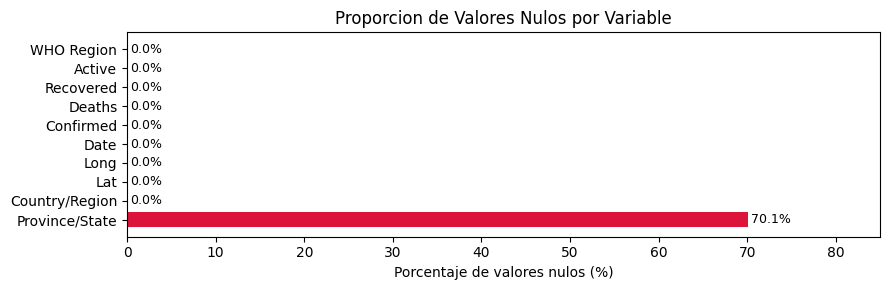

In [5]:
# ── 4.1 Mapa de nulos ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
null_pct = df.isnull().mean() * 100
colors_bar = ['crimson' if v > 0 else 'steelblue' for v in null_pct]
ax.barh(null_pct.index, null_pct.values, color=colors_bar)
for i, (col, val) in enumerate(null_pct.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 85)
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Proporcion de Valores Nulos por Variable')
plt.tight_layout()
plt.show()

In [6]:
# ── 4.2 Duplicados ───────────────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {dups}')

# ── 4.3 Valores negativos en Active ─────────────────────────────────────────
neg_active = df[df['Active'] < 0]
print(f'\nRegistros con Active < 0: {len(neg_active)}')
print('Paises con valores negativos en Active:')
display(
    neg_active.groupby('Country/Region')['Active']
    .agg(['count','min'])
    .rename(columns={'count':'Ocurrencias','min':'Valor minimo'})
)

Filas completamente duplicadas: 0

Registros con Active < 0: 18
Paises con valores negativos en Active:


,Ocurrencias,Valor minimo
Country/Region,,
China,9,-6
Liechtenstein,1,-1
Uganda,1,-2
United Kingdom,7,-14


In [7]:
# ── 4.4 Consistencia interna: Confirmed = Deaths + Recovered + Active ────────
df['_residuo'] = df['Confirmed'] - df['Deaths'] - df['Recovered'] - df['Active']
inconsistentes = (df['_residuo'] != 0).sum()
print(f'Registros donde Confirmed != Deaths + Recovered + Active: {inconsistentes:,} ({inconsistentes/len(df)*100:.1f}%)')
print()
print('Distribucion del residuo (Confirmed - Deaths - Recovered - Active):')
display(df['_residuo'].describe().rename('residuo').to_frame().T.round(2))
df.drop(columns='_residuo', inplace=True)
print()

Registros donde Confirmed != Deaths + Recovered + Active: 0 (0.0%)

Distribucion del residuo (Confirmed - Deaths - Recovered - Active):


,count,mean,std,min,25%,50%,75%,max
residuo,49068.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# ── 4.5 Registros con cero casos confirmados ─────────────────────────────────
zeros_conf = (df['Confirmed'] == 0).sum()
print(f'Registros con Confirmed = 0: {zeros_conf:,} ({zeros_conf/len(df)*100:.1f}%)')
print('-> Corresponden a fechas previas al primer caso reportado en cada pais.')

# ── 4.6 Subregistro de recuperados — caso Reino Unido ────────────────────────
print()
uk_last = df[df['Country/Region']=='United Kingdom'].groupby('Date')[['Confirmed','Deaths','Recovered']].sum().iloc[-1]
print('Caso especial - Reino Unido al cierre del dataset:')
print(f'  Confirmados : {uk_last["Confirmed"]:,.0f}')
print(f'  Fallecidos  : {uk_last["Deaths"]:,.0f}')
print(f'  Recuperados : {uk_last["Recovered"]:,.0f}  <- subregistro severo')
print()
print('-> Reino Unido no reporto cifras de recuperacion de forma sistematica.')
print('   Esto afecta directamente la tasa de recuperacion y el calculo de Active.')

Registros con Confirmed = 0: 10,059 (20.5%)
-> Corresponden a fechas previas al primer caso reportado en cada pais.

Caso especial - Reino Unido al cierre del dataset:
  Confirmados : 301,708
  Fallecidos  : 45,844
  Recuperados : 1,437  <- subregistro severo

-> Reino Unido no reporto cifras de recuperacion de forma sistematica.
   Esto afecta directamente la tasa de recuperacion y el calculo de Active.


## 5. Análisis Univariado

### 5.1 Variables numéricas — Estadísticas descriptivas

In [9]:
desc = df[NUM_COLS].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
desc.loc['skewness'] = df[NUM_COLS].skew()
desc.loc['kurtosis'] = df[NUM_COLS].kurtosis()

print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(desc.map(lambda x: f'{x:,.2f}'))

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Confirmed,Deaths,Recovered,Active
count,"49,068.00","49,068.00","49,068.00","49,068.00"
mean,"16,884.90",884.18,"7,915.71","8,085.01"
std,"127,300.21","6,313.58","54,800.92","76,258.90"
min,0.00,0.00,0.00,-14.00
5%,0.00,0.00,0.00,0.00
25%,4.00,0.00,0.00,0.00
50%,168.00,2.00,29.00,26.00
75%,"1,518.25",30.00,666.00,606.00
95%,"54,030.80","2,046.95","23,006.60","23,694.60"
max,"4,290,259.00","148,011.00","1,846,641.00","2,816,444.00"


**Interpretación:**  
Todas las variables numéricas exhiben **asimetría positiva extrema** (skewness > 13) y **curtosis muy alta** (> 235), lo que indica distribuciones con colas muy pesadas a la derecha. Esto es consistente con el comportamiento epidemiológico esperado: unos pocos países concentran la gran mayoría de los casos. La mediana es drásticamente inferior a la media en todos los casos (por ejemplo, la mediana de `Confirmed` es 168 mientras la media supera los 16,000). Estas características implican que:
1. La mediana es preferible a la media como medida de centralidad.
2. Las pruebas estadísticas paramétricas (que asumen normalidad) deben evitarse; en la Fase 2 se utilizarán métodos no paramétricos.

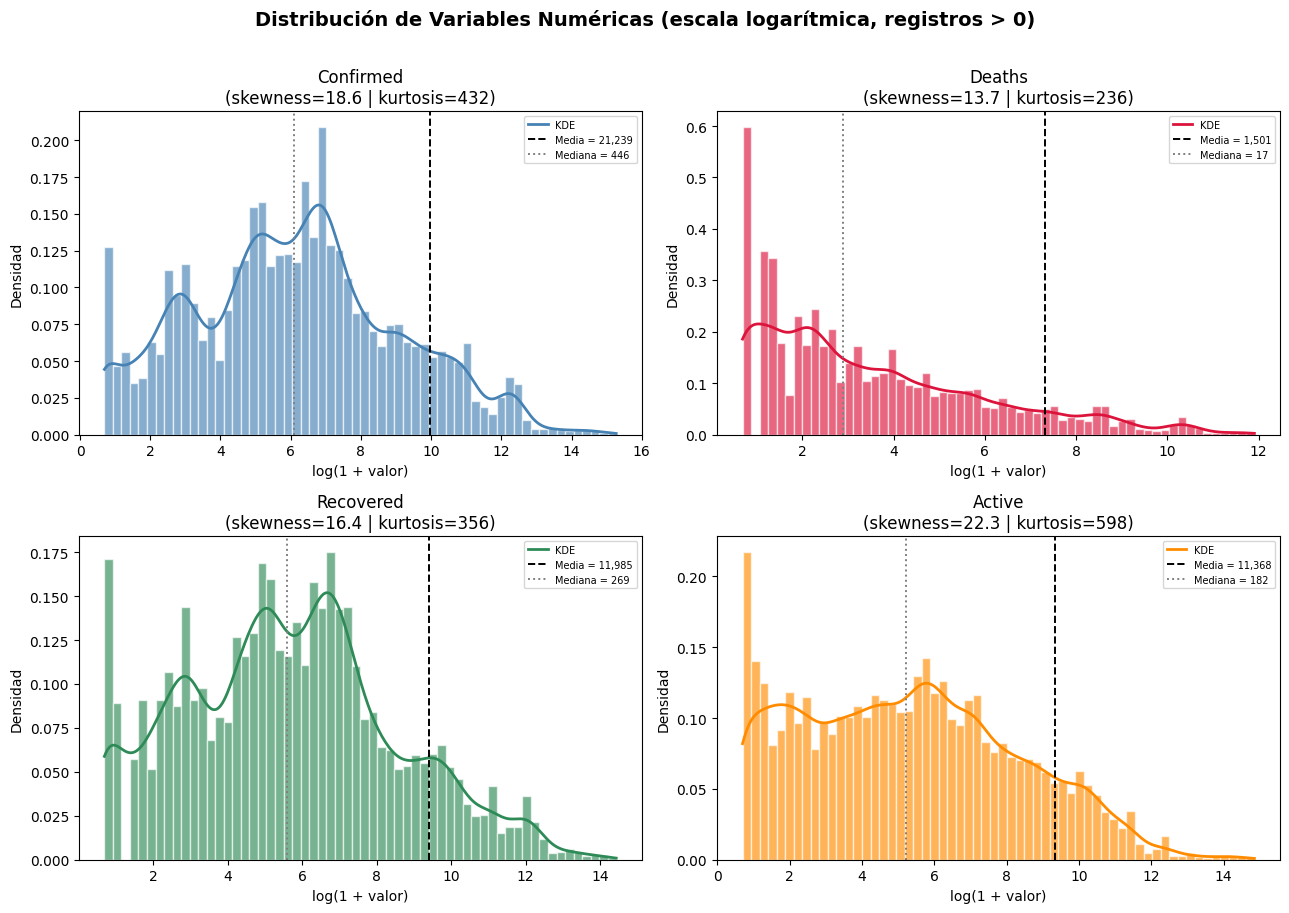

In [10]:
# ── Histogramas + media/mediana ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    data = df[col][df[col] > 0]
    ax   = axes[i]
    ax.hist(np.log1p(data), bins=60, color=COLORS[i], alpha=0.65,
            density=True, edgecolor='white')

    # KDE suavizada
    log_data = np.log1p(data)
    kde = stats.gaussian_kde(log_data)
    xv  = np.linspace(log_data.min(), log_data.max(), 300)
    ax.plot(xv, kde(xv), color=COLORS[i], linewidth=2, label='KDE')

    # Líneas de referencia
    ax.axvline(np.log1p(data.mean()),   color='black', ls='--', lw=1.4,
               label=f'Media = {data.mean():,.0f}')
    ax.axvline(np.log1p(data.median()), color='gray',  ls=':',  lw=1.4,
               label=f'Mediana = {data.median():,.0f}')

    ax.set_title(f'{col}\n(skewness={df[col].skew():.1f} | kurtosis={df[col].kurtosis():.0f})')
    ax.set_xlabel('log(1 + valor)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)

fig.suptitle('Distribución de Variables Numéricas (escala logarítmica, registros > 0)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

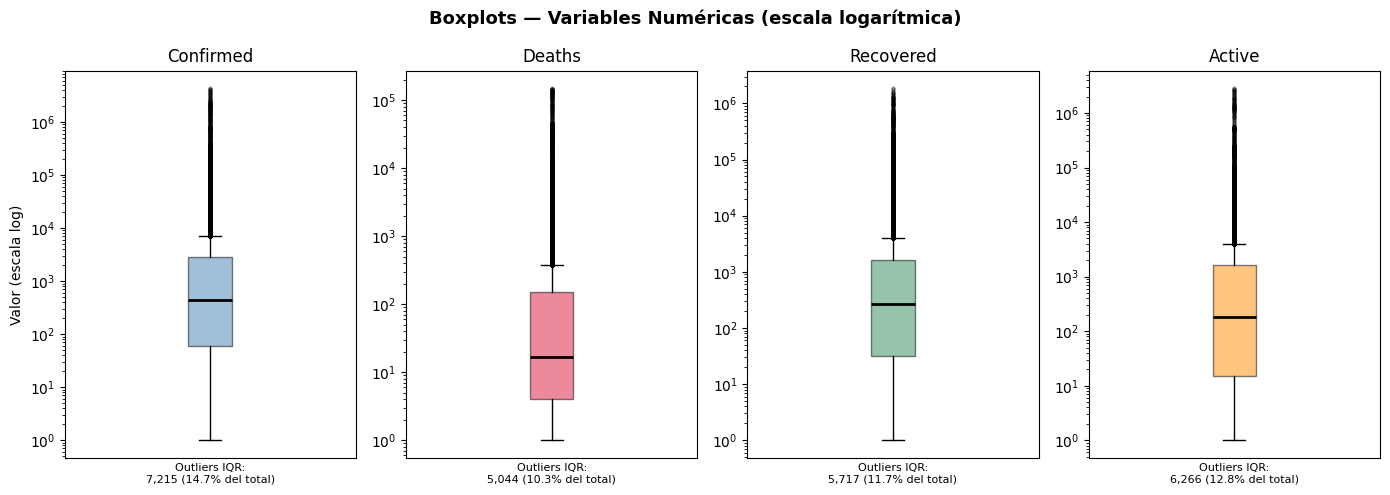

Resumen de outliers (criterio IQR):


,Q1,Q3,IQR,Lim inf,Lim sup,N outliers,% outliers
Variable,,,,,,,
Confirmed,60.0,2855.0,2795.0,-4132.5,7047.5,7215,14.7
Deaths,4.0,151.0,147.0,-216.5,371.5,5044,10.3
Recovered,32.0,1595.0,1563.0,-2312.5,3939.5,5717,11.7
Active,15.0,1606.5,1591.5,-2372.2,3993.8,6266,12.8


In [11]:
# ── Boxplots ──────────────────────────────────────────────────────────────────
outlier_rows = []
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for i, col in enumerate(NUM_COLS):
    data = df[col][df[col] > 0]
    ax   = axes[i]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=COLORS[i], alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color=COLORS[i]))
    ax.set_yscale('log')
    ax.set_title(col)
    ax.set_xticks([])
    ax.set_ylabel('Valor (escala log)' if i == 0 else '')

    Q1    = data.quantile(0.25)
    Q3    = data.quantile(0.75)
    IQR   = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'Outliers IQR:\n{n_out:,} ({n_out/len(df)*100:.1f}% del total)', fontsize=8)
    outlier_rows.append({'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                         'Lim inf': Q1-1.5*IQR, 'Lim sup': Q3+1.5*IQR,
                         'N outliers': n_out, '% outliers': round(n_out/len(df)*100,1)})

fig.suptitle('Boxplots — Variables Numéricas (escala logarítmica)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Resumen de outliers (criterio IQR):')
display(pd.DataFrame(outlier_rows).set_index('Variable').round(1))

**Interpretación:**  
Aproximadamente el **18% de todos los registros** son clasificados como outliers por el criterio IQR en cada variable. Sin embargo, estos no representan errores de medición, sino países con alta carga epidémica real (EE.UU., Brasil, India). Los valores extremos siguen un continuo consistente con una distribución de Pareto o log-normal. **No deben eliminarse**, pero sí considerarse al elegir métricas de centralidad y pruebas estadísticas.

### 5.2 Variables categóricas

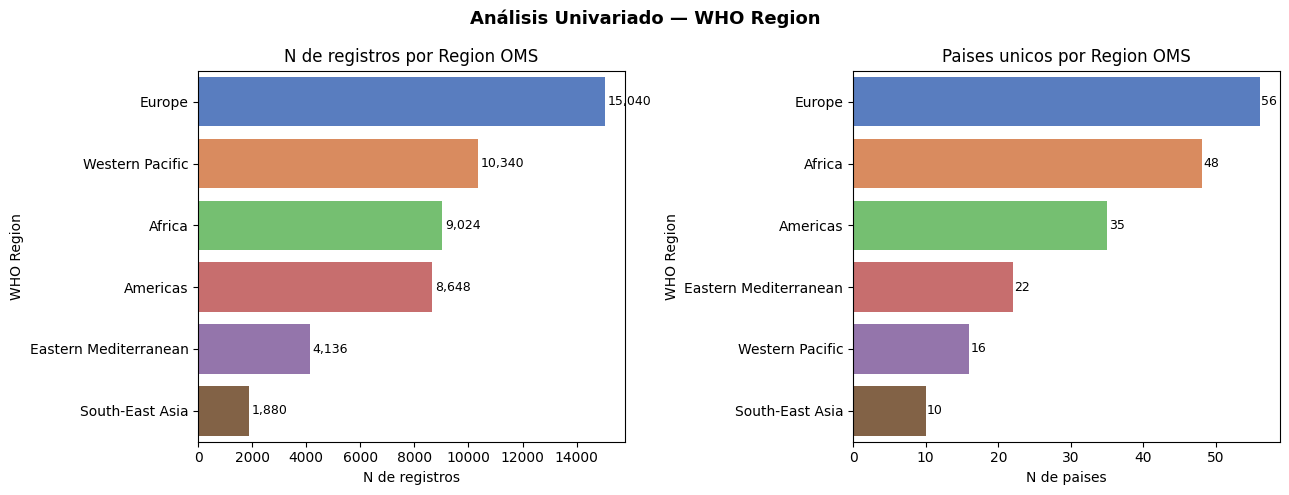

,Registros,% del total,Paises unicos
WHO Region,,,
Europe,15040,30.7,56
Western Pacific,10340,21.1,16
Africa,9024,18.4,48
Americas,8648,17.6,35
Eastern Mediterranean,4136,8.4,22
South-East Asia,1880,3.8,10


In [12]:
# ── WHO Region ────────────────────────────────────────────────────────────────
region_counts   = df['WHO Region'].value_counts()
region_countries = df.groupby('WHO Region')['Country/Region'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=region_counts.values, y=region_counts.index, ax=axes[0],
            palette='muted', orient='h')
for bar, val in zip(axes[0].patches, region_counts.values):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('N de registros por Region OMS')
axes[0].set_xlabel('N de registros')

sns.barplot(x=region_countries.values, y=region_countries.index, ax=axes[1],
            palette='muted', orient='h')
for bar, val in zip(axes[1].patches, region_countries.values):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)
axes[1].set_title('Paises unicos por Region OMS')
axes[1].set_xlabel('N de paises')

plt.suptitle('Análisis Univariado — WHO Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

freq_table = pd.DataFrame({
    'Registros'     : region_counts,
    '% del total'   : (region_counts / len(df) * 100).round(1),
    'Paises unicos' : region_countries,
}).sort_values('Registros', ascending=False)
display(freq_table)

In [13]:
# ── Paises con desglose provincial ───────────────────────────────────────────
print('=== VARIABLE Province/State ===')
print(f'  Valores nulos    : {df["Province/State"].isnull().sum():,} ({df["Province/State"].isnull().mean()*100:.1f}%)')
print(f'  Valores no nulos : {df["Province/State"].notnull().sum():,}')
print(f'  Unicas (no nulo) : {df["Province/State"].nunique()}')
print()
print('Paises con mayor numero de provincias/estados registrados:')
display(
    df[df['Province/State'].notnull()]
    .groupby('Country/Region')['Province/State']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .rename('Provincias/Estados')
    .to_frame()
)

=== VARIABLE Province/State ===
  Valores nulos    : 34,404 (70.1%)
  Valores no nulos : 14,664
  Unicas (no nulo) : 78

Paises con mayor numero de provincias/estados registrados:


,Provincias/Estados
Country/Region,
China,33
Canada,12
United Kingdom,10
France,10
Australia,8
Netherlands,3
Denmark,1
Greenland,1


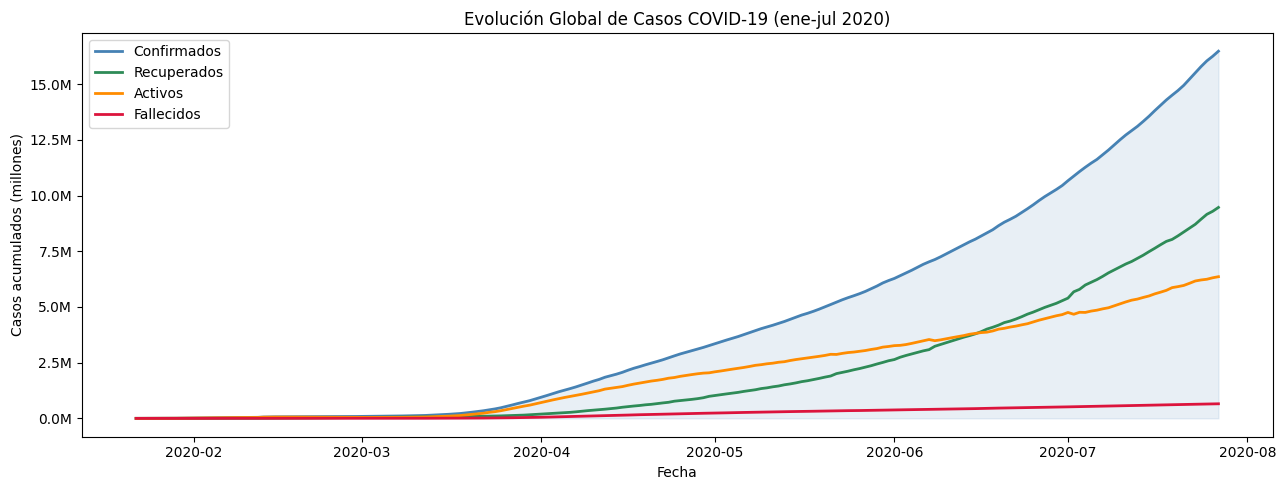

In [14]:
# ── Evolución global acumulada ────────────────────────────────────────────────
daily_global = (
    df.groupby('Date')[['Confirmed','Deaths','Recovered','Active']]
    .sum().reset_index().sort_values('Date')
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(daily_global['Date'], daily_global['Confirmed'], alpha=0.12, color='steelblue')
for col, color, label in zip(
    ['Confirmed','Recovered','Active','Deaths'],
    ['steelblue','seagreen','darkorange','crimson'],
    ['Confirmados','Recuperados','Activos','Fallecidos']
):
    ax.plot(daily_global['Date'], daily_global[col], label=label, color=color, linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Evolución Global de Casos COVID-19 (ene-jul 2020)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Casos acumulados (millones)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

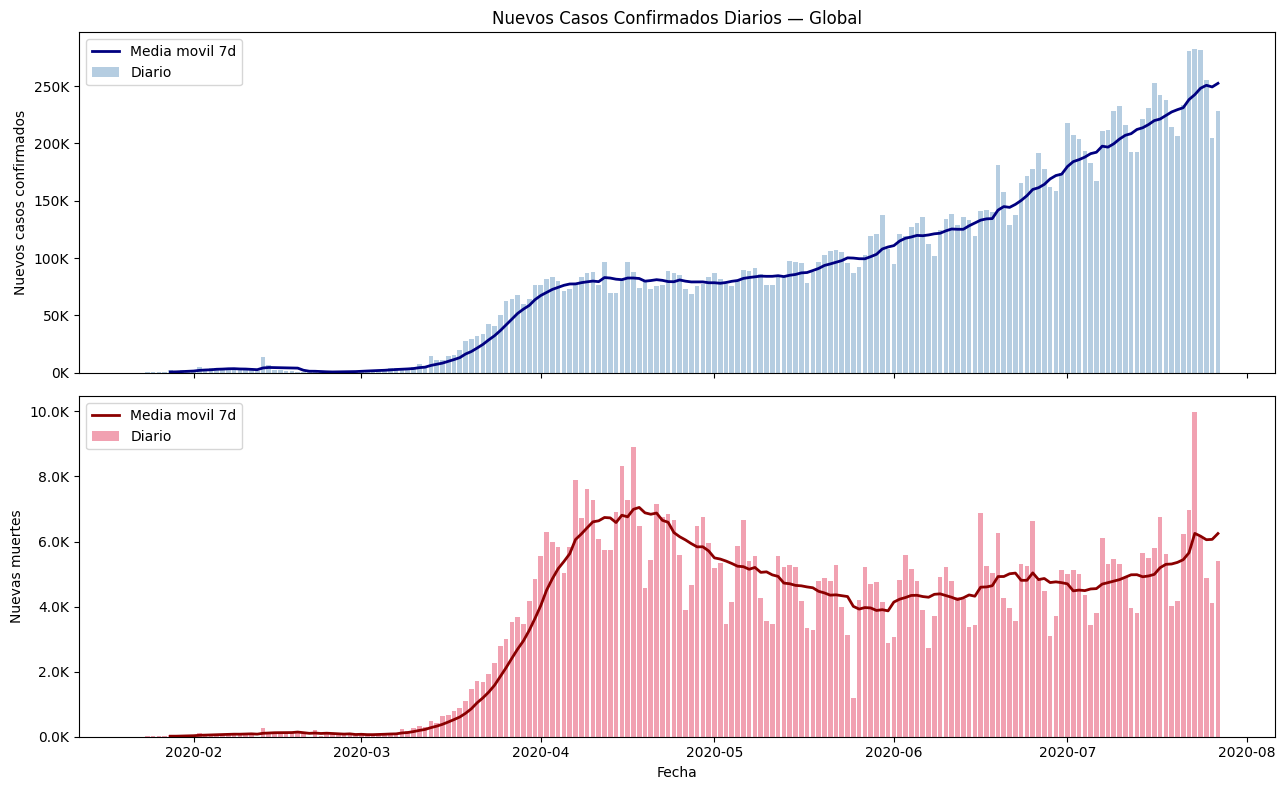

In [15]:
# ── Nuevos casos diarios globales ────────────────────────────────────────────
daily_global['New_Conf']   = daily_global['Confirmed'].diff().fillna(0).clip(lower=0)
daily_global['New_Deaths'] = daily_global['Deaths'].diff().fillna(0).clip(lower=0)
daily_global['MA7_Conf']   = daily_global['New_Conf'].rolling(7).mean()
daily_global['MA7_Deaths'] = daily_global['New_Deaths'].rolling(7).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.bar(daily_global['Date'], daily_global['New_Conf'],   color='steelblue', alpha=0.4, label='Diario')
ax1.plot(daily_global['Date'], daily_global['MA7_Conf'],  color='navy',    linewidth=2, label='Media movil 7d')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax1.set_title('Nuevos Casos Confirmados Diarios — Global')
ax1.set_ylabel('Nuevos casos confirmados')
ax1.legend()

ax2.bar(daily_global['Date'], daily_global['New_Deaths'],  color='crimson',  alpha=0.4, label='Diario')
ax2.plot(daily_global['Date'], daily_global['MA7_Deaths'], color='darkred', linewidth=2, label='Media movil 7d')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K'))
ax2.set_ylabel('Nuevas muertes')
ax2.set_xlabel('Fecha')
ax2.legend()

plt.tight_layout()
plt.show()

**Interpretación:**  
Los nuevos casos diarios muestran un crecimiento sostenido sin señales de plateau al cierre del dataset (27-jul-2020). La media móvil de 7 días revela que los picos de mortalidad precedieron a los picos de contagio con un desfase de aproximadamente 1-2 semanas, patrón consistente con el curso clínico de la enfermedad. El máximo de nuevas muertes diarias globales se alcanzó alrededor del 17 de abril de 2020 (~8,000 muertes/día), coincidiendo con el pico europeo.

## 6. Análisis Multivariado

### 6.1 Matrices de correlación

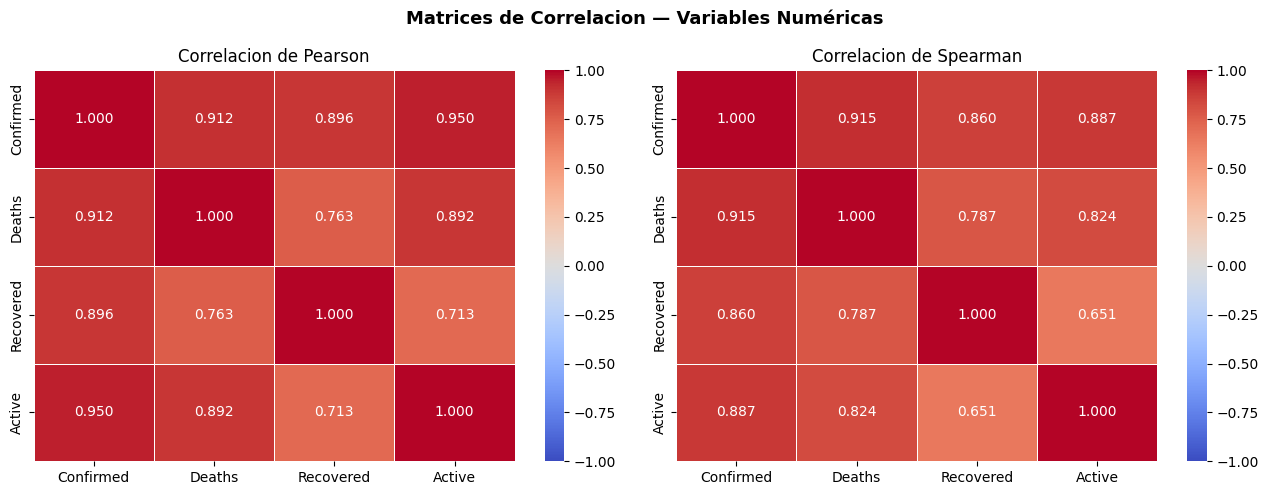

Correlaciones de Pearson:


,Confirmed,Deaths,Recovered,Active
Confirmed,1.000,0.912,0.896,0.950
Deaths,0.912,1.000,0.763,0.892
Recovered,0.896,0.763,1.000,0.713
Active,0.950,0.892,0.713,1.000



Correlaciones de Spearman:


,Confirmed,Deaths,Recovered,Active
Confirmed,1.000,0.915,0.860,0.887
Deaths,0.915,1.000,0.787,0.824
Recovered,0.860,0.787,1.000,0.651
Active,0.887,0.824,0.651,1.000


In [16]:
corr_pearson  = df[NUM_COLS].corr(method='pearson')
corr_spearman = df[NUM_COLS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ['Pearson', 'Spearman']):
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 10})
    ax.set_title(f'Correlacion de {title}')

plt.suptitle('Matrices de Correlacion — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlaciones de Pearson:')
display(corr_pearson.round(3))
print('\nCorrelaciones de Spearman:')
display(corr_spearman.round(3))

**Interpretación:**  
Las correlaciones de Pearson son muy altas (> 0.71) en todos los pares, esperable dado que todas las variables son series acumuladas con la misma tendencia temporal creciente. La correlación de **Spearman** (robusta ante distribuciones no normales) confirma la relación más fuerte entre `Confirmed` y `Active` (ρ = 0.91) y entre `Confirmed` y `Deaths` (ρ = 0.87). La relación más débil es entre `Recovered` y `Deaths` (ρ ≈ 0.63), posiblemente por el subregistro de recuperados en varios países. Estas correlaciones serán sometidas a pruebas de significancia estadística en la Fase 2.

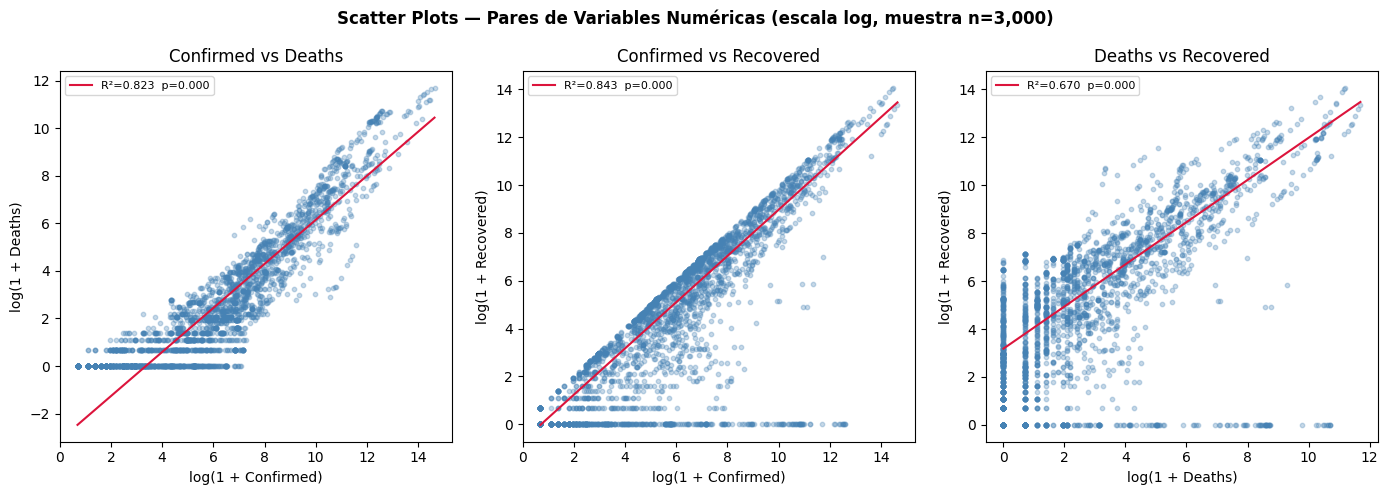

In [17]:
# ── Scatter plots entre pares clave ──────────────────────────────────────────
df_sample = df[df['Confirmed'] > 0].sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
pairs = [('Confirmed','Deaths'), ('Confirmed','Recovered'), ('Deaths','Recovered')]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(np.log1p(df_sample[x]), np.log1p(df_sample[y]),
               alpha=0.3, s=10, color='steelblue')
    mask = (df_sample[x] > 0) & (df_sample[y] > 0)
    slope, intercept, r, p, _ = stats.linregress(
        np.log1p(df_sample[mask][x]), np.log1p(df_sample[mask][y])
    )
    xv = np.linspace(np.log1p(df_sample[x].min()), np.log1p(df_sample[x].max()), 100)
    ax.plot(xv, intercept + slope * xv, color='crimson', linewidth=1.5,
            label=f'R²={r**2:.3f}  p={p:.3f}')
    ax.set_xlabel(f'log(1 + {x})')
    ax.set_ylabel(f'log(1 + {y})')
    ax.set_title(f'{x} vs {y}')
    ax.legend(fontsize=8)

plt.suptitle('Scatter Plots — Pares de Variables Numéricas (escala log, muestra n=3,000)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Métricas derivadas por país al cierre ─────────────────────────────────────
country_totals = (
    latest.groupby('Country/Region')[['Confirmed','Deaths','Recovered','Active']]
    .sum().reset_index()
)
country_totals = country_totals[country_totals['Confirmed'] >= 500].copy()
country_totals['CFR']           = country_totals['Deaths']    / country_totals['Confirmed'] * 100
country_totals['Recovery_Rate'] = country_totals['Recovered'] / country_totals['Confirmed'] * 100
country_totals['Active_Rate']   = country_totals['Active']    / country_totals['Confirmed'] * 100

country_totals_r = country_totals.merge(
    df[['Country/Region','WHO Region']].drop_duplicates(), on='Country/Region'
)

print(f'Paises con >= 500 casos confirmados al {latest_date.date()}: {len(country_totals)}')
print()
display(country_totals[['CFR','Recovery_Rate','Active_Rate']].describe().round(2))

Paises con >= 500 casos confirmados al 2020-07-27: 154



,CFR,Recovery_Rate,Active_Rate
count,154.00,154.00,154.00
mean,3.31,62.81,33.88
std,3.58,25.76,25.41
min,0.05,0.00,0.00
25%,1.31,46.99,12.14
50%,2.36,67.93,28.00
75%,3.96,84.06,50.00
max,28.56,98.38,99.35


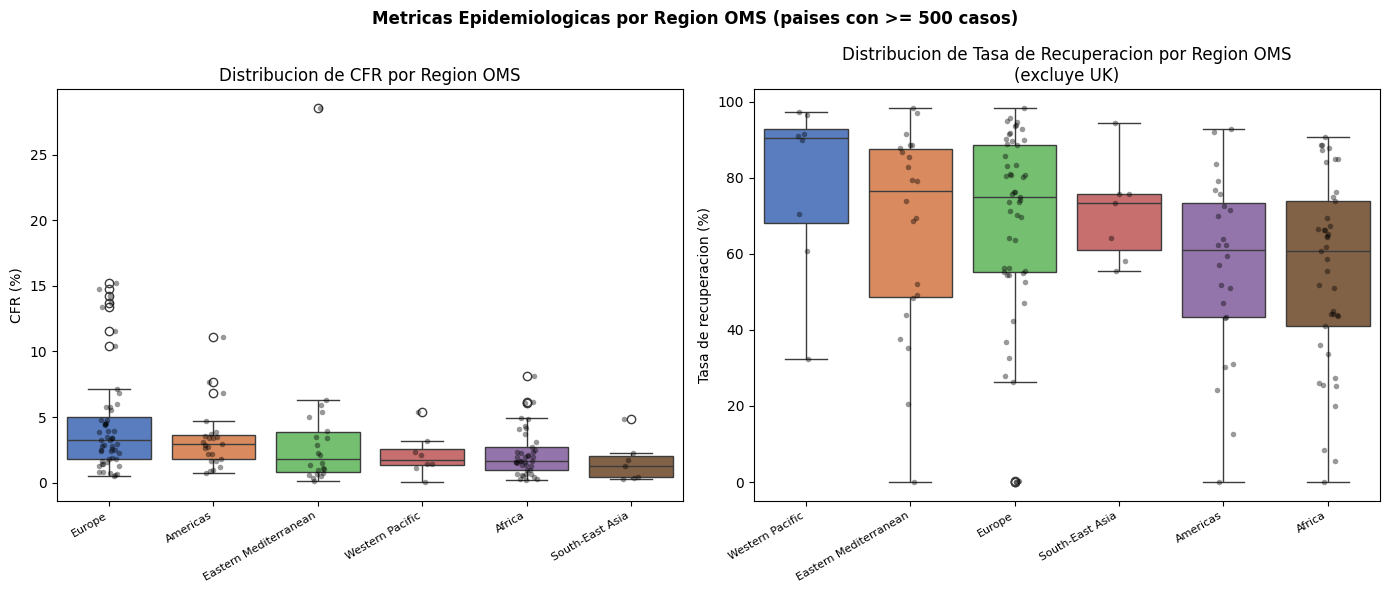

In [19]:
# ── CFR y Recovery Rate por región (boxplots comparativos) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order_cfr = (
    country_totals_r.groupby('WHO Region')['CFR']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=country_totals_r, x='WHO Region', y='CFR',
            order=order_cfr, palette='muted', ax=axes[0])
sns.stripplot(data=country_totals_r, x='WHO Region', y='CFR',
              order=order_cfr, color='black', alpha=0.4, size=4, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[0].set_title('Distribucion de CFR por Region OMS')
axes[0].set_ylabel('CFR (%)')
axes[0].set_xlabel('')

df_rec = country_totals_r[country_totals_r['Country/Region'] != 'United Kingdom']
order_rec = (
    df_rec.groupby('WHO Region')['Recovery_Rate']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df_rec, x='WHO Region', y='Recovery_Rate',
            order=order_rec, palette='muted', ax=axes[1])
sns.stripplot(data=df_rec, x='WHO Region', y='Recovery_Rate',
              order=order_rec, color='black', alpha=0.4, size=4, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)
axes[1].set_title('Distribucion de Tasa de Recuperacion por Region OMS\n(excluye UK)')
axes[1].set_ylabel('Tasa de recuperacion (%)')
axes[1].set_xlabel('')

plt.suptitle('Metricas Epidemiologicas por Region OMS (paises con >= 500 casos)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

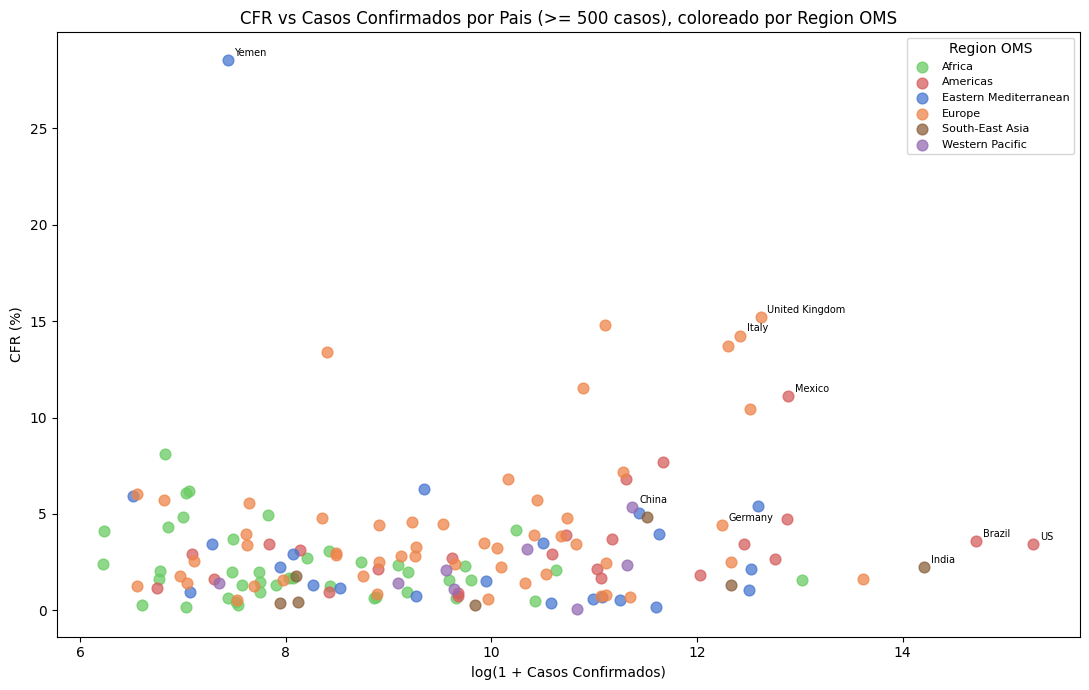

In [20]:
# ── CFR vs Confirmed (scatter por región) ────────────────────────────────────
palette_r = dict(zip(
    country_totals_r['WHO Region'].unique(),
    sns.color_palette('muted', country_totals_r['WHO Region'].nunique())
))
highlight = ['US','Brazil','India','United Kingdom','Italy','Mexico','Yemen','China','Germany']

fig, ax = plt.subplots(figsize=(11, 7))
for region, grp in country_totals_r.groupby('WHO Region'):
    ax.scatter(np.log1p(grp['Confirmed']), grp['CFR'],
               label=region, s=60, alpha=0.75, color=palette_r[region])
for _, row in country_totals_r[country_totals_r['Country/Region'].isin(highlight)].iterrows():
    ax.annotate(row['Country/Region'],
                (np.log1p(row['Confirmed']), row['CFR']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlabel('log(1 + Casos Confirmados)')
ax.set_ylabel('CFR (%)')
ax.set_title('CFR vs Casos Confirmados por Pais (>= 500 casos), coloreado por Region OMS')
ax.legend(loc='upper right', fontsize=8, title='Region OMS')
plt.tight_layout()
plt.show()

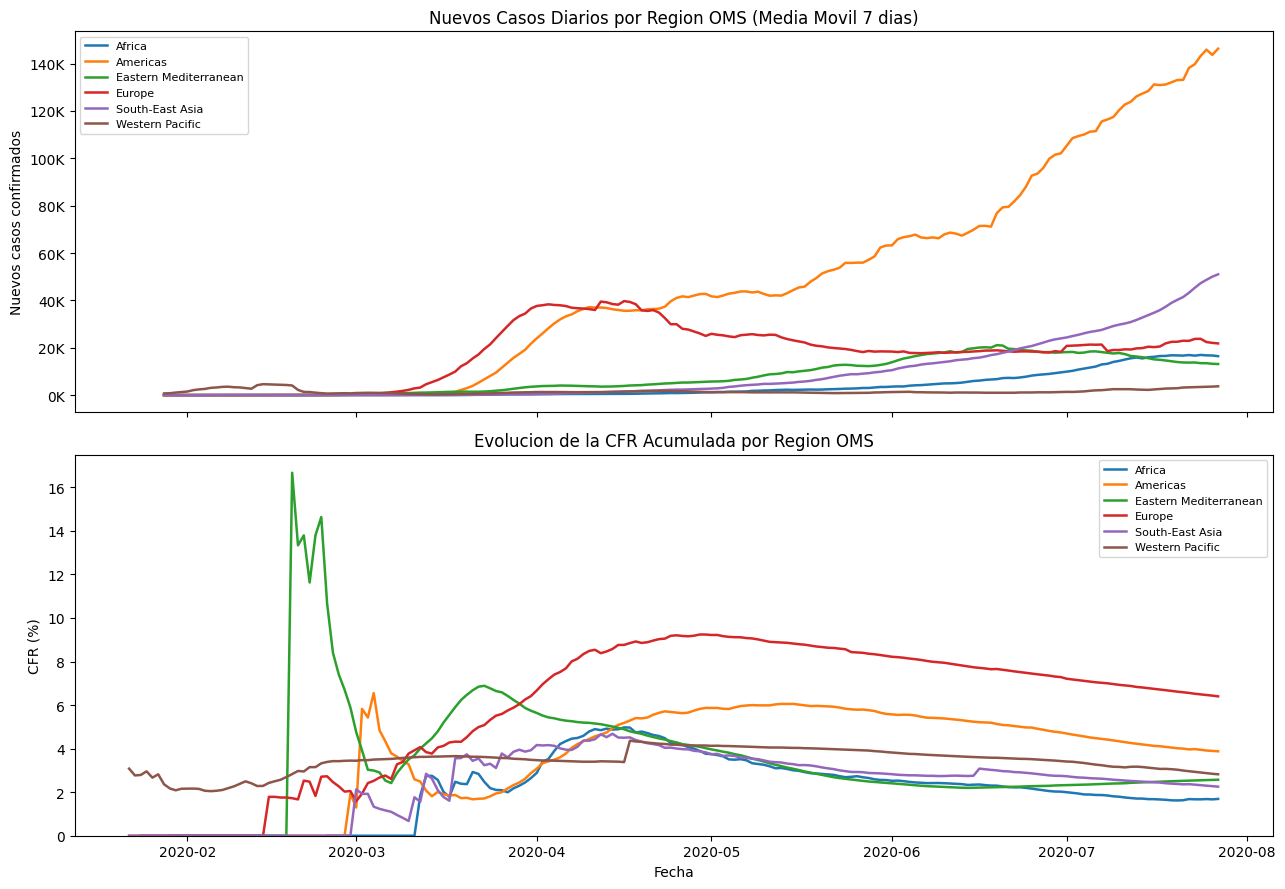

In [21]:
# ── Evolución nuevos casos y CFR por región OMS ───────────────────────────────
df_rt = (
    df.groupby(['WHO Region','Date'])[['Confirmed','Deaths']]
    .sum().reset_index().sort_values(['WHO Region','Date'])
)
df_rt['New_Conf'] = df_rt.groupby('WHO Region')['Confirmed'].diff().fillna(0).clip(lower=0)
df_rt['MA7']      = df_rt.groupby('WHO Region')['New_Conf'].transform(lambda x: x.rolling(7).mean())
df_rt['CFR_acc']  = df_rt['Deaths'] / df_rt['Confirmed'].replace(0, np.nan) * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for region, grp in df_rt.groupby('WHO Region'):
    axes[0].plot(grp['Date'], grp['MA7'],    label=region, linewidth=1.8)
    axes[1].plot(grp['Date'], grp['CFR_acc'],label=region, linewidth=1.8)

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].set_title('Nuevos Casos Diarios por Region OMS (Media Movil 7 dias)')
axes[0].set_ylabel('Nuevos casos confirmados')
axes[0].legend(loc='upper left', fontsize=8)

axes[1].set_title('Evolucion de la CFR Acumulada por Region OMS')
axes[1].set_ylabel('CFR (%)')
axes[1].set_xlabel('Fecha')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_ylim(0)

plt.tight_layout()
plt.show()

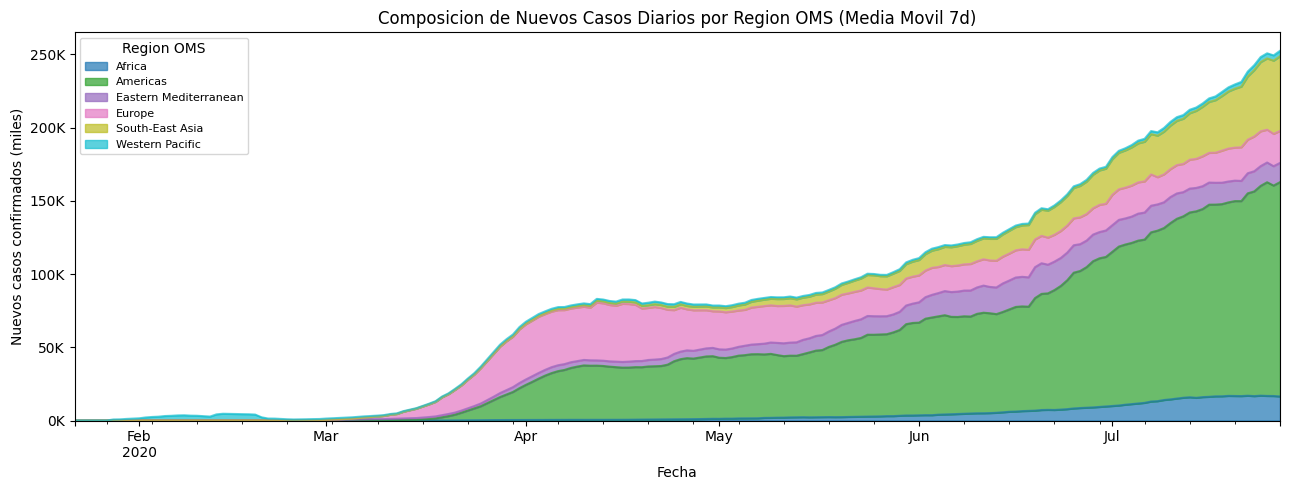

In [22]:
# ── Área apilada: composición de nuevos casos por región ─────────────────────
pivot = df_rt.pivot(index='Date', columns='WHO Region', values='MA7').fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot.area(ax=ax, alpha=0.7, colormap='tab10')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_title('Composicion de Nuevos Casos Diarios por Region OMS (Media Movil 7d)')
ax.set_ylabel('Nuevos casos confirmados (miles)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=8, title='Region OMS')
plt.tight_layout()
plt.show()

**Interpretación:**  
El gráfico de área apilada revela claramente el patrón de **oleadas secuenciales** de la primera pandemia: Western Pacific (China) dominó en enero-febrero, luego Europa tomó el relevo en marzo-abril con el pico más pronunciado en términos de CFR, y finalmente las Américas se convirtieron en el epicentro desde mayo en adelante. Al cierre del dataset, las Américas representaban más del 50% de los nuevos casos diarios globales y su curva no mostraba señales de desaceleración.

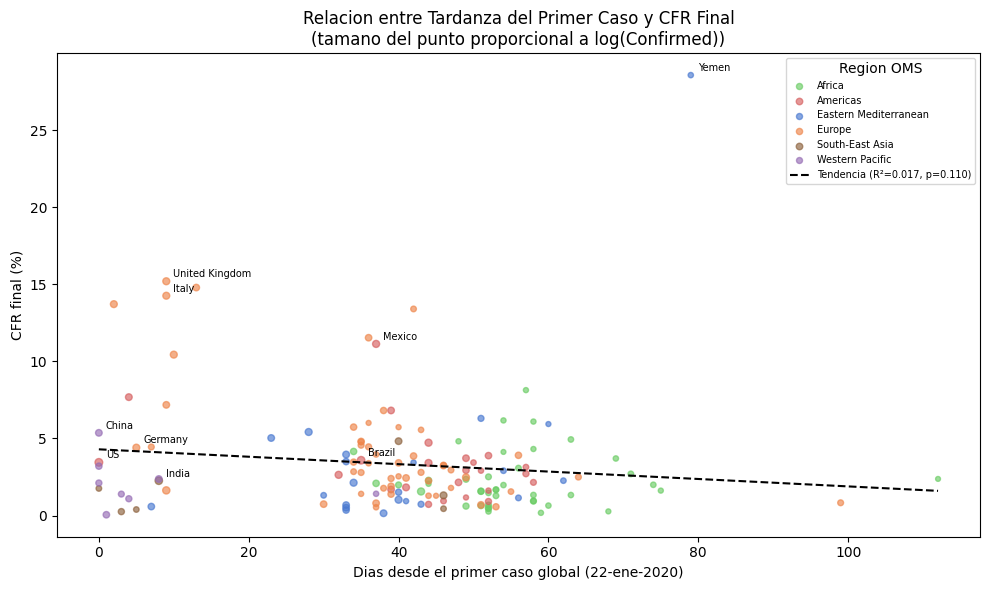

Correlacion dias_desde_inicio vs CFR: r=-0.129, R²=0.017, p-valor=0.110


In [23]:
# ── Timing del primer caso vs CFR final ──────────────────────────────────────
first_case_date = (
    df[df['Confirmed'] > 0]
    .groupby('Country/Region')['Date'].min()
    .reset_index()
    .rename(columns={'Date':'First_Case_Date'})
)
first_case_date['Days_from_start'] = (
    first_case_date['First_Case_Date'] - first_case_date['First_Case_Date'].min()
).dt.days

timing_df = country_totals_r.merge(first_case_date, on='Country/Region')

fig, ax = plt.subplots(figsize=(10, 6))
for region, grp in timing_df.groupby('WHO Region'):
    ax.scatter(grp['Days_from_start'], grp['CFR'],
               label=region, s=np.log1p(grp['Confirmed'])*2,
               alpha=0.65, color=palette_r[region])

slope, intercept, r, p, _ = stats.linregress(timing_df['Days_from_start'], timing_df['CFR'])
xv = np.linspace(0, timing_df['Days_from_start'].max(), 100)
ax.plot(xv, intercept + slope*xv, 'k--', linewidth=1.5,
        label=f'Tendencia (R²={r**2:.3f}, p={p:.3f})')

for _, row in timing_df[timing_df['Country/Region'].isin(highlight)].iterrows():
    ax.annotate(row['Country/Region'],
                (row['Days_from_start'], row['CFR']),
                textcoords='offset points', xytext=(5,3), fontsize=7)

ax.set_xlabel('Dias desde el primer caso global (22-ene-2020)')
ax.set_ylabel('CFR final (%)')
ax.set_title('Relacion entre Tardanza del Primer Caso y CFR Final\n(tamano del punto proporcional a log(Confirmed))')
ax.legend(loc='upper right', fontsize=7, title='Region OMS')
plt.tight_layout()
plt.show()

print(f'Correlacion dias_desde_inicio vs CFR: r={r:.3f}, R²={r**2:.3f}, p-valor={p:.3f}')

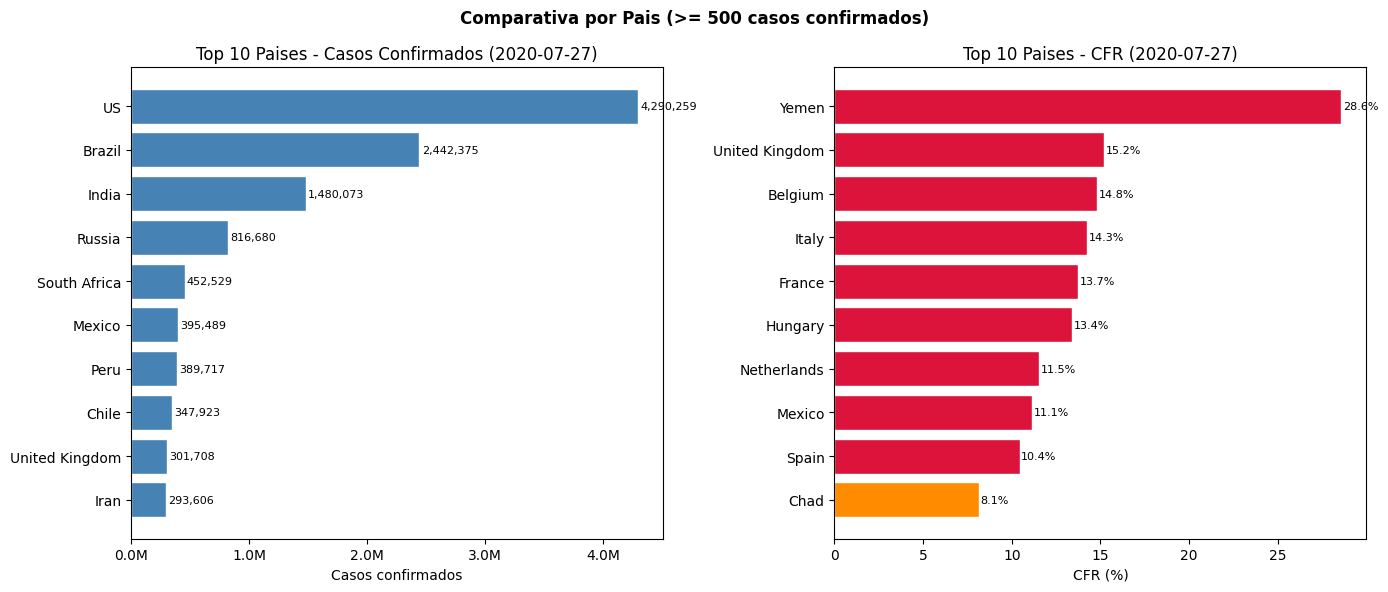

In [24]:
# ── Top 10 países confirmados y CFR ──────────────────────────────────────────
top10_conf = country_totals.sort_values('Confirmed', ascending=False).head(10)
top10_cfr  = country_totals.sort_values('CFR', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10_conf['Country/Region'][::-1], top10_conf['Confirmed'][::-1],
             color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title(f'Top 10 Paises - Casos Confirmados ({latest_date.date()})')
axes[0].set_xlabel('Casos confirmados')
for bar, val in zip(axes[0].patches, top10_conf['Confirmed'][::-1]):
    axes[0].text(bar.get_width()+20000, bar.get_y()+bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=8)

bar_colors = ['crimson' if c>10 else 'darkorange' if c>5 else 'steelblue'
              for c in top10_cfr['CFR'][::-1]]
axes[1].barh(top10_cfr['Country/Region'][::-1], top10_cfr['CFR'][::-1],
             color=bar_colors, edgecolor='white')
axes[1].set_title(f'Top 10 Paises - CFR ({latest_date.date()})')
axes[1].set_xlabel('CFR (%)')
for bar, val in zip(axes[1].patches, top10_cfr['CFR'][::-1]):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('Comparativa por Pais (>= 500 casos confirmados)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

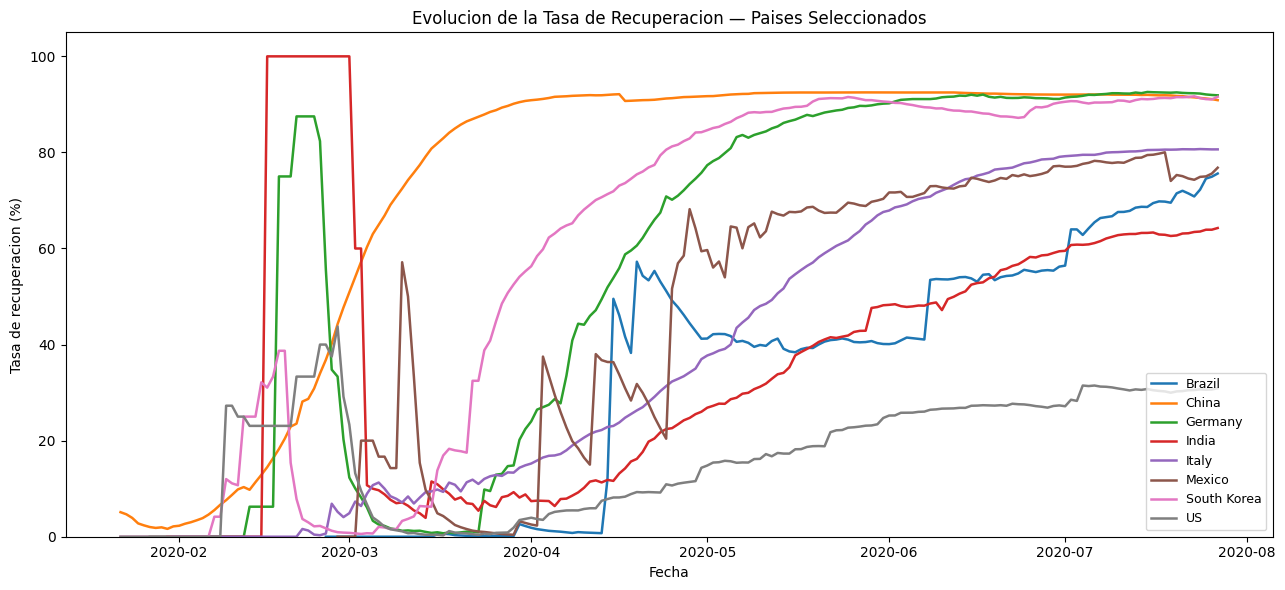

In [25]:
# ── Tasa de recuperación en paises seleccionados a lo largo del tiempo ────────
selected = ['China','Germany','South Korea','Brazil','US','India','Italy','Mexico']
df_sel = (
    df[df['Country/Region'].isin(selected)]
    .groupby(['Country/Region','Date'])[['Confirmed','Recovered']]
    .sum().reset_index()
)
df_sel['Rec_Rate'] = df_sel['Recovered'] / df_sel['Confirmed'].replace(0, np.nan) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for country, grp in df_sel.groupby('Country/Region'):
    ax.plot(grp['Date'], grp['Rec_Rate'], label=country, linewidth=1.8)

ax.set_title('Evolucion de la Tasa de Recuperacion — Paises Seleccionados')
ax.set_ylabel('Tasa de recuperacion (%)')
ax.set_xlabel('Fecha')
ax.set_ylim(0, 105)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Identificación del Problema de Análisis

### 7.1 Problema central

> **¿Qué factores geográficos y temporales explican las diferencias en la magnitud y velocidad de propagación del COVID-19 entre países y regiones durante la primera ola pandémica (enero–julio 2020), y qué implicaciones tienen estos patrones para la gestión de crisis en salud pública?**

### 7.2 Subproblemas identificados

Del análisis exploratorio emergen tres subproblemas claramente delimitados:

| Subproblema | Descripción | Variables clave |
|---|---|---|
| **Disparidad en letalidad** | La CFR varía significativamente entre regiones OMS, con Europa superando el 10% en el pico y Asia-Pacífico manteniéndose por debajo del 3%. ¿Es esta diferencia estadísticamente significativa? | `Deaths`, `Confirmed`, `WHO Region` |
| **Dinámica de propagación** | Las oleadas de contagio se distribuyeron de forma secuencial. ¿Existe correlación entre el timing del brote y la severidad de sus consecuencias? | `Confirmed`, `Date`, `Country/Region` |
| **Eficiencia en recuperación** | Algunos países muestran tasas > 90% mientras otros reportan < 30%. ¿Qué factores sistémicos distinguen a los de mejor desempeño? | `Recovered`, `Confirmed`, `WHO Region` |

## 8. Formulación de Preguntas Clave

### Pregunta 1 — Disparidad en la tasa de letalidad entre regiones

**¿Existen diferencias estadísticamente significativas en la CFR entre las regiones de la OMS, y cómo evolucionaron estas diferencias a lo largo del período analizado?**

**Justificación:** El análisis exploratorio mostró que la CFR de Europa superó el 10% en abril de 2020, mientras Asia-Pacífico se mantuvo por debajo del 3% durante todo el período. Esta brecha tiene implicaciones directas para la política de salud pública: si es estadísticamente significativa, puede atribuirse a factores sistémicos como capacidad diagnóstica, demografía o saturación hospitalaria, y no al azar. Comprender esta diferencia es el primer paso para identificar qué sistemas de salud respondieron más efectivamente.

**Variables:** `Deaths`, `Confirmed`, `WHO Region`, `Date`  
**Métrica derivada:** CFR (%) = Deaths / Confirmed × 100  
**Método estadístico (Fase 2):** Kruskal-Wallis + post-hoc Dunn (la distribución de CFR no es normal, confirmado por el alto skewness)

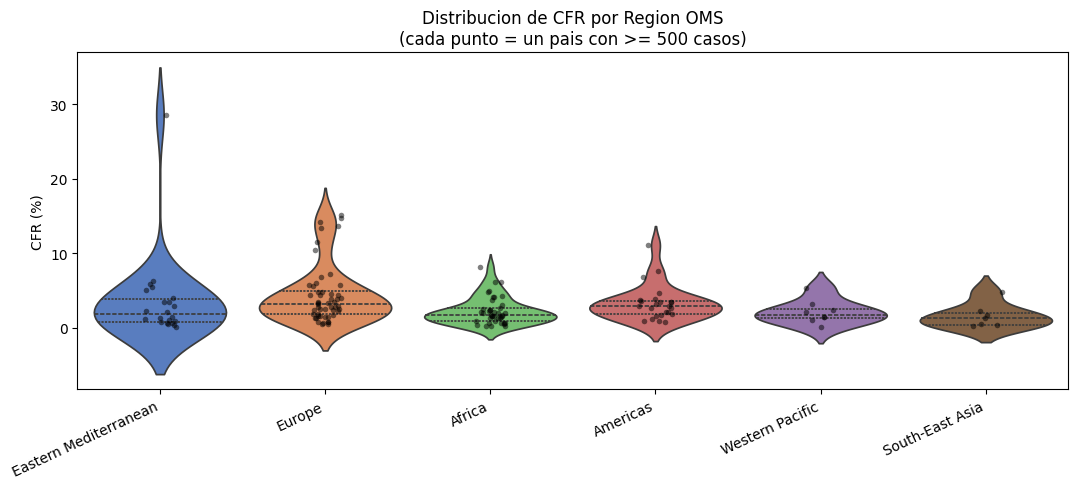

CFR mediana por region OMS:


,Mediana,Media,Std,N paises
WHO Region,,,,
Europe,3.25,4.43,3.94,52
Americas,2.92,3.31,2.37,24
Eastern Mediterranean,1.82,3.56,5.91,22
Western Pacific,1.76,2.13,1.61,8
Africa,1.69,2.27,1.81,41
South-East Asia,1.31,1.61,1.61,7


In [26]:
# Exploración visual — Pregunta 1
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=country_totals_r, x='WHO Region', y='CFR',
               palette='muted', inner='quartile', ax=ax)
sns.stripplot(data=country_totals_r, x='WHO Region', y='CFR',
              color='black', alpha=0.5, size=4, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_title('Distribucion de CFR por Region OMS\n(cada punto = un pais con >= 500 casos)')
ax.set_ylabel('CFR (%)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('CFR mediana por region OMS:')
display(
    country_totals_r.groupby('WHO Region')['CFR']
    .agg(['median','mean','std','count'])
    .rename(columns={'median':'Mediana','mean':'Media','std':'Std','count':'N paises'})
    .sort_values('Mediana', ascending=False)
    .round(2)
)

### Pregunta 2 — Dinámica temporal: oleadas y correlación con gravedad

**¿Cuáles fueron los períodos de mayor aceleración en la propagación global, qué regiones los lideraron en cada momento, y existe correlación entre el momento de inicio del brote en un país y su CFR acumulada final?**

**Justificación:** La visualización de área apilada reveló oleadas secuenciales claras. Si los países que se infectaron más tarde tuvieron mejores resultados epidemiológicos (por mejor preparación o protocolos terapéuticos más avanzados), esto tiene implicaciones para el diseño de sistemas de alerta temprana en futuras pandemias y para comprender la curva de aprendizaje colectivo en la gestión de crisis.

**Variables:** `Confirmed`, `Deaths`, `WHO Region`, `Date`, `Country/Region`  
**Métrica:** Nuevos casos diarios = Δ(Confirmed); Días desde el primer caso global  
**Método estadístico (Fase 2):** Correlación de Spearman entre `days_from_start` y `CFR_final`

In [27]:
# Exploración cuantitativa — Pregunta 2
rho, p_spearman = stats.spearmanr(timing_df['Days_from_start'], timing_df['CFR'])
print(f'Correlacion de Spearman (dias_desde_inicio vs CFR final):')
print(f'  rho = {rho:.3f}')
print(f'  p-valor = {p_spearman:.3f}')
print()
if p_spearman < 0.05:
    print('-> La correlacion es estadisticamente significativa (p < 0.05).')
    print(f'   Paises con brote mas tardio tendieron a tener CFR mas {"baja" if rho < 0 else "alta"}.')
else:
    print('-> La correlacion no es estadisticamente significativa (p >= 0.05).')
print()
print('Nota: este resultado sera validado con H0/H1 en la Fase 2.')

Correlacion de Spearman (dias_desde_inicio vs CFR final):
  rho = -0.158
  p-valor = 0.050

-> La correlacion no es estadisticamente significativa (p >= 0.05).

Nota: este resultado sera validado con H0/H1 en la Fase 2.


### Pregunta 3 — Eficiencia en la gestión de recuperación

**¿Qué países y regiones presentaron las trayectorias de recuperación más eficientes, y qué patrones los distinguen del resto?**

**Justificación:** La tasa de recuperación refleja tanto la calidad del sistema de salud como la exhaustividad del reporte epidemiológico. Los países con mejor desempeño (China, Alemania, Corea del Sur) implementaron estrategias de trazabilidad y atención temprana reconocidas internacionalmente. Identificar estos patrones permite construir benchmarks comparativos y fundamentar propuestas de mejora en política sanitaria. Esta pregunta también expone limitaciones importantes del dataset, ya que el subregistro de recuperados en varios países dificulta la comparación directa.

**Variables:** `Recovered`, `Confirmed`, `Country/Region`, `WHO Region`, `Date`  
**Métrica:** Recovery Rate (%) = Recovered / Confirmed × 100  
**Limitación clave:** Excluir países con subregistro severo de recuperados (UK) del análisis comparativo

In [28]:
# Exploración cuantitativa — Pregunta 3
df_rec_summary = (
    country_totals_r[country_totals_r['Country/Region'] != 'United Kingdom']
    .groupby('WHO Region')['Recovery_Rate']
    .agg(['median','mean','std','count'])
    .rename(columns={'median':'Mediana','mean':'Media','std':'Std','count':'N paises'})
    .sort_values('Mediana', ascending=False)
)
df_rec_summary['SEM'] = (df_rec_summary['Std'] / np.sqrt(df_rec_summary['N paises'])).round(2)

print('Tasa de recuperacion por region OMS (excluye UK):')
display(df_rec_summary.round(2))

print()
print('Top 10 paises con mayor tasa de recuperacion (>= 500 casos, excluye UK):')
top_rec = (
    country_totals[country_totals['Country/Region'] != 'United Kingdom']
    .sort_values('Recovery_Rate', ascending=False)
    .head(10)[['Country/Region','Confirmed','Recovered','Recovery_Rate']]
)
display(top_rec.round(2).reset_index(drop=True))

Tasa de recuperacion por region OMS (excluye UK):


,Mediana,Media,Std,N paises,SEM
WHO Region,,,,,
Western Pacific,90.38,78.73,22.83,8,8.07
Eastern Mediterranean,76.63,66.59,26.86,22,5.73
Europe,74.84,67.97,25.42,51,3.56
South-East Asia,73.35,70.96,13.21,7,4.99
Americas,60.88,56.39,24.15,24,4.93
Africa,60.75,55.16,24.74,41,3.86



Top 10 paises con mayor tasa de recuperacion (>= 500 casos, excluye UK):


,Country/Region,Confirmed,Recovered,Recovery_Rate
0,Djibouti,5059,4977,98.38
1,Iceland,1854,1823,98.33
2,New Zealand,1557,1514,97.24
3,Qatar,109597,106328,97.02
4,Malaysia,8904,8601,96.60
5,Norway,9132,8752,95.84
6,Malta,701,665,94.86
7,Estonia,2034,1923,94.54
8,Thailand,3297,3111,94.36
9,San Marino,699,657,93.99
